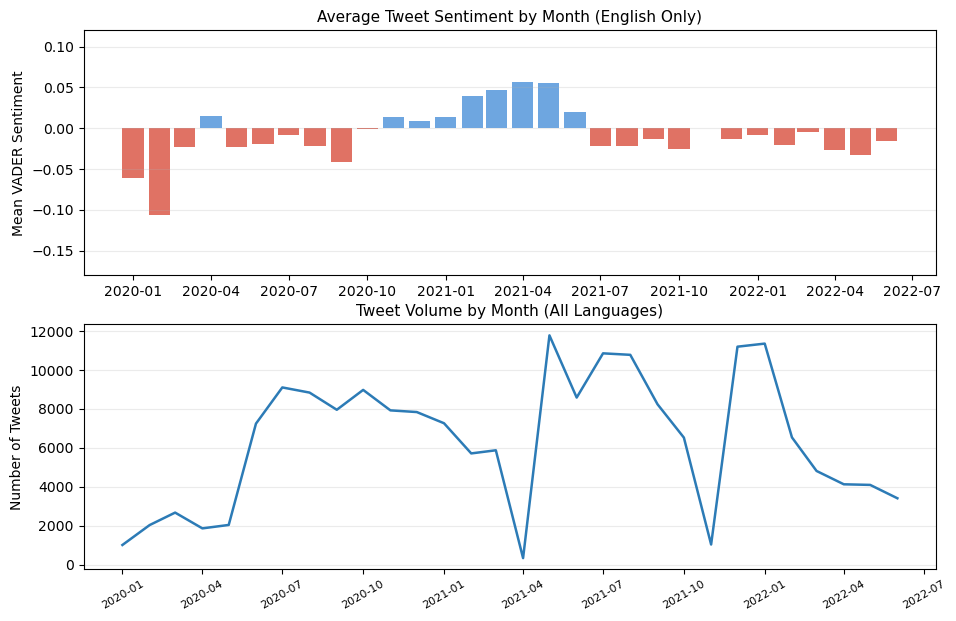

In [6]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#loading data
df = pd.read_pickle('/Users/pranavakella/Documents/GitHub/FinalProj/data/covid_sample-0.0001.pkl')
#parsing
df['date_parsed'] = pd.to_datetime(
    df['date'],
    format='%a %b %d %H:%M:%S +0000 %Y',
    errors='coerce'
)
df['month'] = df['date_parsed'].dt.to_period('M')

#sentiment analyasis
en_df = df[df['lang'] == 'en'].copy()
monthly_sent = en_df.groupby('month')['sent_vader'].mean()

monthly_count = df.groupby('month').size()


months_sent_dt  = monthly_sent.index.to_timestamp()
months_count_dt = monthly_count.index.to_timestamp()

#Plotting 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), facecolor='white')
#fig1
colors = ['#D94F3D' if v < 0 else '#4A90D9' for v in monthly_sent.values]
ax1.bar(months_sent_dt, monthly_sent.values, width=25, color=colors, alpha=0.8)


ax1.set_ylabel('Mean VADER Sentiment', fontsize=10)
ax1.set_title('Average Tweet Sentiment by Month (English Only)', fontsize=11)
ax1.set_ylim(-0.18, 0.12)

ax1.grid(axis='y', alpha=0.25)


# Fig2
ax2.plot(months_count_dt, monthly_count.values, color='#2C7BB6', linewidth=1.8)
ax2.fill_between(months_count_dt, monthly_count.values, alpha=0.15, color='#2C7BB6')

ax2.set_ylabel('Number of Tweets', fontsize=10)
ax2.set_title('Tweet Volume by Month (All Languages)', fontsize=11)
ax2.grid(axis='y', alpha=0.25)
ax2.tick_params(axis='x', labelsize=8, rotation=30)
plt.show()
